<a href="https://colab.research.google.com/github/ronan-cunha/machine-learning-course/blob/main/Notebooks/aula_7_probabilistic_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
# Carrega o dataset Fair (sobre casos extraconjugais)
# https://www.statsmodels.org/stable/datasets/generated/fair.html
affair = sm.datasets.fair.load_pandas()
df_real = affair.data
display(df_real.head())

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666


In [38]:
# A variável dependente binária 'had_affair'(1 é sim e 0 é não)
df_real['had_affair'] = (affair.endog > 0).astype(int)
display(df_real.head())

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs,had_affair
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111,1
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769,1
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000,1
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273,1
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666,1


In [39]:
df_real.describe()

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs,had_affair
count,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000
mean,4.109645,29.082862,9.009425,1.396874,2.426170,14.209865,3.424128,3.850141,0.705374,0.322495
std,0.961430,6.847882,7.280120,1.433471,0.878369,2.178003,0.942399,1.346435,2.203374,0.467468
min,1.000000,17.500000,0.500000,0.000000,1.000000,9.000000,1.000000,1.000000,0.000000,0.000000
25%,4.000000,22.000000,2.500000,0.000000,2.000000,12.000000,3.000000,3.000000,0.000000,0.000000
50%,4.000000,27.000000,6.000000,1.000000,2.000000,14.000000,3.000000,4.000000,0.000000,0.000000
75%,5.000000,32.000000,16.500000,2.000000,3.000000,16.000000,4.000000,5.000000,0.484848,1.000000
max,5.000000,42.000000,23.000000,5.500000,4.000000,20.000000,6.000000,6.000000,57.599991,1.000000


### Linear Probability Model (LPM)

In [123]:
lpm_model = smf.ols('had_affair ~ rate_marriage + age + educ', data=df_real).fit()
print(lpm_model.summary())

                            OLS Regression Results                            
Dep. Variable:             had_affair   R-squared:                       0.125
Model:                            OLS   Adj. R-squared:                  0.125
Method:                 Least Squares   F-statistic:                     303.1
Date:                Tue, 15 Sep 2026   Prob (F-statistic):          5.98e-184
Time:                        21:51:28   Log-Likelihood:                -3766.3
No. Observations:                6366   AIC:                             7541.
Df Residuals:                    6362   BIC:                             7568.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.8900      0.048     18.358

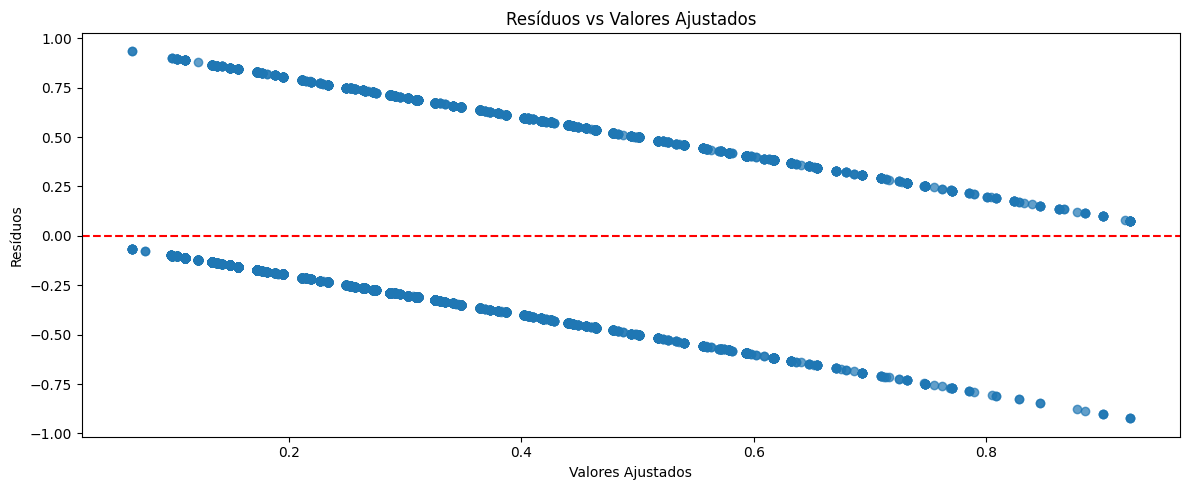

In [124]:
# Extraindo resíduos e valores ajustados
residuos = lpm_model.resid
valores_ajustados = lpm_model.fittedvalues

# Configurando o painel de diagnósticos visuais
fig, axes = plt.subplots(1, 1, figsize=(12, 5))

# 1. Resíduos vs Valores Ajustados
axes.scatter(valores_ajustados, residuos, alpha=0.7)
axes.axhline(0, color='red', linestyle='--')
axes.set_title('Resíduos vs Valores Ajustados')
axes.set_xlabel('Valores Ajustados')
axes.set_ylabel('Resíduos')

plt.tight_layout()
plt.show()

In [125]:
# Estimador robusto de White
# https://www.statsmodels.org/stable/generated/statsmodels.tsa.ar_model.AutoReg.fit.html
lpm_model_rob = smf.ols('had_affair ~ rate_marriage + age + educ', data=df_real).fit(cov_type='HC3')
print(lpm_model_rob.summary())

                            OLS Regression Results                            
Dep. Variable:             had_affair   R-squared:                       0.125
Model:                            OLS   Adj. R-squared:                  0.125
Method:                 Least Squares   F-statistic:                     309.2
Date:                Tue, 15 Sep 2026   Prob (F-statistic):          2.23e-187
Time:                        21:51:39   Log-Likelihood:                -3766.3
No. Observations:                6366   AIC:                             7541.
Df Residuals:                    6362   BIC:                             7568.
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.8900      0.049     18.131

### Logit Model

In [43]:
logit_model = smf.logit('had_affair ~ rate_marriage + age + educ', data=df_real).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.566110
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:             had_affair   No. Observations:                 6366
Model:                          Logit   Df Residuals:                     6362
Method:                           MLE   Df Model:                            3
Date:                Tue, 15 Sep 2026   Pseudo R-squ.:                 0.09961
Time:                        21:17:34   Log-Likelihood:                -3603.9
converged:                       True   LL-Null:                       -4002.5
Covariance Type:            nonrobust   LLR p-value:                1.624e-172
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         1.8751      0.253      7.420      0.000       1.380       2.370
rate_marriage    -0.

In [98]:
# Calcular os efeitos marginais do modelo Logit
logit_mfx = logit_model.get_margeff(at='overall', #at='median'
                                    method='dydx')
print("\nMarginal Effects for Logit Model:")
print(logit_mfx.summary())


Marginal Effects for Logit Model:
        Logit Marginal Effects       
Dep. Variable:             had_affair
Method:                          dydx
At:                           overall
                   dy/dx    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
rate_marriage    -0.1382      0.005    -28.245      0.000      -0.148      -0.129
age               0.0074      0.001      9.600      0.000       0.006       0.009
educ             -0.0114      0.003     -4.490      0.000      -0.016      -0.006


In [99]:
df_real[['rate_marriage','age', 'educ']].median()

,0
rate_marriage,4.0
age,27.0
educ,14.0


In [101]:
# Calcular os efeitos marginais do modelo Logit quando todos os regressores são zer0
logit_mfx = logit_model.get_margeff(at='zero', #at='median'
                                    method='dydx')
print("\nMarginal Effects for Logit Model:")
print(logit_mfx.summary())


Marginal Effects for Logit Model:
        Logit Marginal Effects       
Dep. Variable:             had_affair
Method:                          dydx
At:                              zero
                   dy/dx    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
rate_marriage    -0.0834      0.014     -5.880      0.000      -0.111      -0.056
age               0.0045      0.001      3.936      0.000       0.002       0.007
educ             -0.0069      0.001     -6.281      0.000      -0.009      -0.005


### Calculando Efeitos Marginais em Valores Específicos

Você pode especificar os valores das variáveis independentes para os quais deseja calcular os efeitos marginais, passando um dicionário para o parâmetro `atexog`. As variáveis não especificadas usarão seus valores médios por padrão.

In [106]:
# Efeitos Marginais em pontos específicos

# 1. Obter os nomes das variáveis exógenas do modelo (incluindo o intercepto)
model_exog_names = logit_model.model.exog_names

# 2. Definir os valores para as variáveis explicativas e o intercepto
# O intercepto (constante) sempre tem valor 1 para o cálculo de efeitos marginais.
specific_values_for_atexog = {
    'Intercept': 1,
    'rate_marriage': 3,
    'age': 20,
    'educ': 5
}

# 3. Criar um DataFrame com uma única linha
atexog_df = pd.DataFrame(
    [specific_values_for_atexog],
    columns=model_exog_names
)

# 4. Converter o DataFrame para um array NumPy 2D
atexog_array = atexog_df.to_numpy()

# 5. Calcular o efeito marginal
specific_values_mfx = logit_model.get_margeff(atexog=atexog_array,
                                              method='dydx')

print("\nMarginal Effects for Logit Model at Specific Values:")
print(specific_values_mfx.summary())


Marginal Effects for Logit Model at Specific Values:
        Logit Marginal Effects       
Dep. Variable:             had_affair
Method:                          dydx
At:                           overall
                   dy/dx    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
rate_marriage    -0.1795      0.007    -23.933      0.000      -0.194      -0.165
age               0.0096      0.001      9.046      0.000       0.008       0.012
educ             -0.0149      0.003     -4.693      0.000      -0.021      -0.009


### Probit Model

In [107]:
probit_model = smf.probit('had_affair ~ rate_marriage + age + educ', data=df_real).fit()
print(probit_model.summary())

Optimization terminated successfully.
         Current function value: 0.565905
         Iterations 5
                          Probit Regression Results                           
Dep. Variable:             had_affair   No. Observations:                 6366
Model:                         Probit   Df Residuals:                     6362
Method:                           MLE   Df Model:                            3
Date:                Tue, 15 Sep 2026   Pseudo R-squ.:                 0.09993
Time:                        21:44:56   Log-Likelihood:                -3602.5
converged:                       True   LL-Null:                       -4002.5
Covariance Type:            nonrobust   LLR p-value:                4.414e-173
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         1.1109      0.150      7.390      0.000       0.816       1.406
rate_marriage    -0.

In [108]:
# Calculate and display marginal effects for Probit model
probit_mfx = probit_model.get_margeff(at='overall', method='dydx')
print("\nMarginal Effects for Probit Model:")
print(probit_mfx.summary())


Marginal Effects for Probit Model:
       Probit Marginal Effects       
Dep. Variable:             had_affair
Method:                          dydx
At:                           overall
                   dy/dx    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
rate_marriage    -0.1398      0.005    -28.233      0.000      -0.149      -0.130
age               0.0076      0.001      9.718      0.000       0.006       0.009
educ             -0.0114      0.003     -4.511      0.000      -0.016      -0.006


### Realizando Previsões com os Modelos

In [130]:
# 1. Definir novos dados para previsão
new_data = pd.DataFrame({
    'rate_marriage': [3, 5, 1],
    'age': [25, 30, 40],
    'educ': [12, 16, 10]
})

# 2. Adicionar a constante aos novos dados
new_data_with_constant = sm.add_constant(new_data, prepend=True)

print("Novos Dados para Previsão:")
display(new_data_with_constant)

# 3. Previsões com o Modelo LPM
lpm_predictions = lpm_model.predict(new_data_with_constant)

# 4. Previsões com o Modelo Logit
logit_predictions = logit_model.predict(new_data_with_constant)

# 5. Previsões com o Modelo Probit
probit_predictions = probit_model.predict(new_data_with_constant)

# 6. Combinar todas as previsões em um único DataFrame para comparação
predictions_df = pd.DataFrame({
    'LPM': lpm_predictions,
    'Logit': logit_predictions,
    'Probit': probit_predictions
})

print("\nPrevisões Combinadas dos Modelos:")
display(predictions_df)

Novos Dados para Previsão:


,const,rate_marriage,age,educ
0,1.0,3,25,12
1,1.0,5,30,16
2,1.0,1,40,10



Previsões Combinadas dos Modelos:


,LPM,Logit,Probit
0,0.486203,0.488977,0.486037
1,0.172747,0.176969,0.175598
2,0.931075,0.891458,0.896933
